In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### loading our dataset

In [2]:
df = pd.read_csv("Superstore sales dataset.csv")

### understanding our dataset

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Checking data quality

In [8]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

### checking and changing data types

In [10]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [12]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [13]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

### Distribution of Categories, Regions, and Customer Segments

In [14]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [15]:
df['Region'].value_counts()

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

In [16]:
df['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

## Sales Analysis by Category

In [17]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

### Visualization of Sales by Category

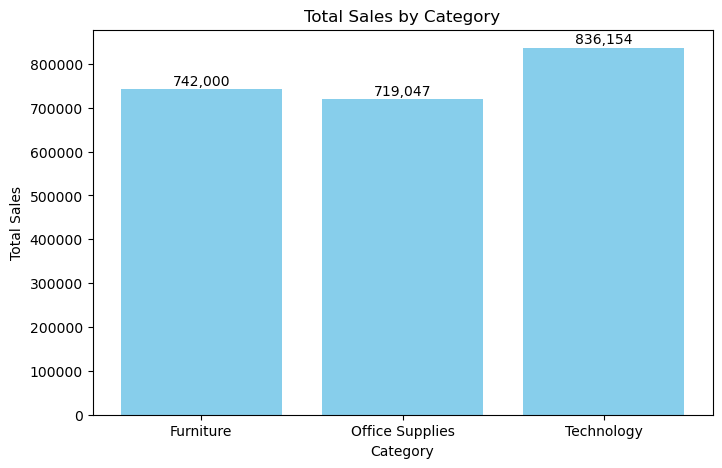

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(category_sales.index, category_sales.values, color="skyblue")

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

for i in range(len(category_sales)):
    plt.text(i, category_sales.values[i]+10000, f'{category_sales.values[i]:,.0f}', ha='center')

### Profit Analysis by Category

In [19]:
category_profit = df.groupby('Category')['Profit'].sum()

category_profit

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

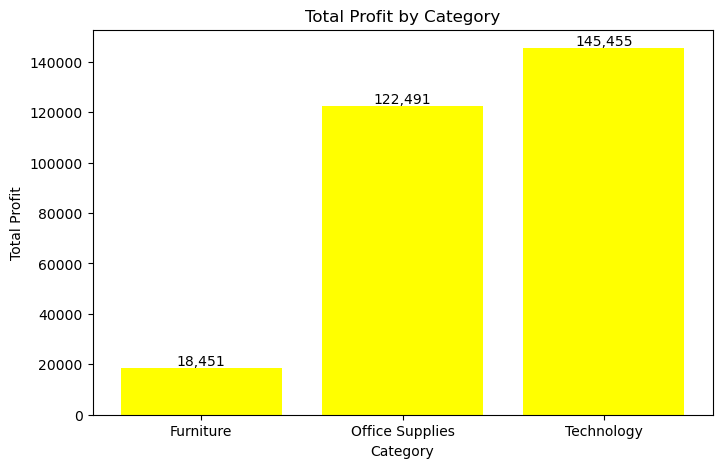

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(category_profit.index, category_profit.values, color="yellow")

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')

for i in range(len(category_profit)):
    plt.text(
        i,
        category_profit.values[i] + 1000,
        f'{category_profit.values[i]:,.0f}',
        ha='center'
    )

### Comparison of Sales and Profit by Category

In [21]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum()

category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


## Sales Analysis by Region

In [22]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

Text(0, 0.5, 'Total Sales')

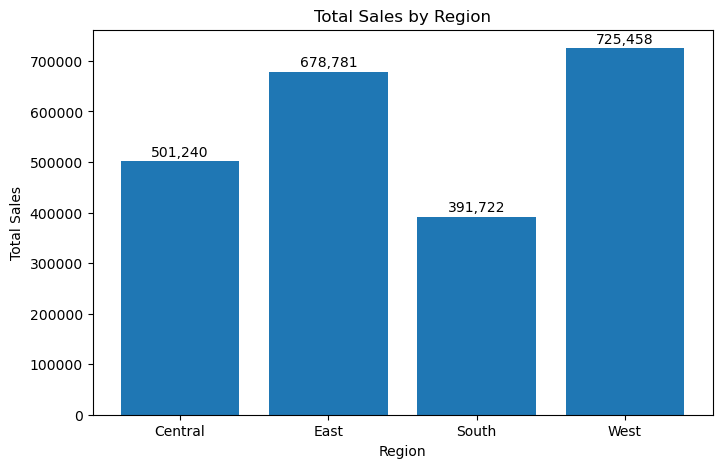

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(region_sales.index, region_sales.values)

for i in range(len(region_sales)):
    plt.text(
        i,
        region_sales.values[i] + 10000,
        f'{region_sales.values[i]:,.0f}',
        ha='center'
    )

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

### Profit Analysis by Region

In [24]:
region_profit = df.groupby('Region')['Profit'].sum()

region_profit

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

Text(0, 0.5, 'Total Profit')

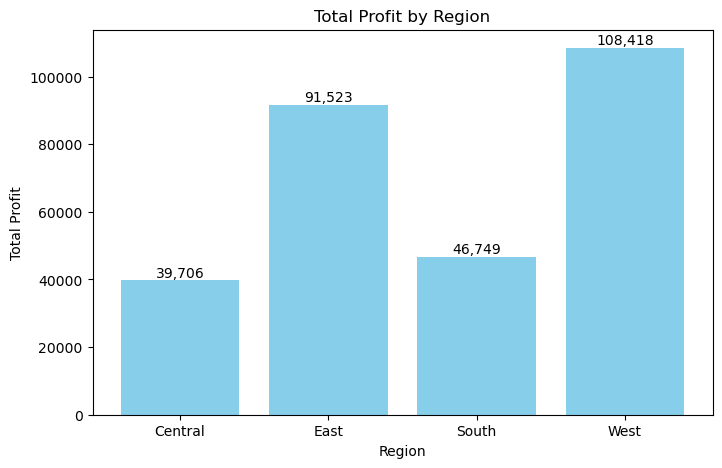

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(region_profit.index, region_profit.values, color="skyblue")

for i in range(len(region_profit)):
    plt.text(
        i,
        region_profit.values[i] + 1000,
        f'{region_profit.values[i]:,.0f}',
        ha='center'
    )

plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')

### Sales Analysis by Customer Segment

In [26]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

Text(0, 0.5, 'Total Sales')

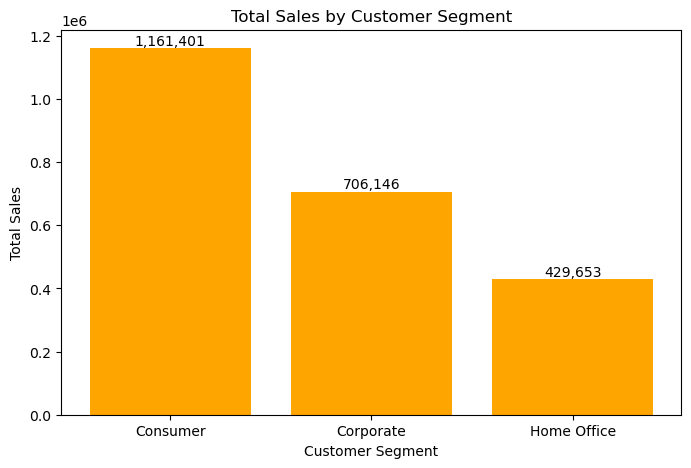

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(segment_sales.index, segment_sales.values, color="orange")

for i in range(len(segment_sales)):
    plt.text(
        i,
        segment_sales.values[i] + 10000,
        f'{segment_sales.values[i]:,.0f}',
        ha='center'
    )

plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')

### Profit Analysis by Customer Segment

In [28]:
segment_profit = df.groupby('Segment')['Profit'].sum()

segment_profit

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

Text(0, 0.5, 'Total Profit')

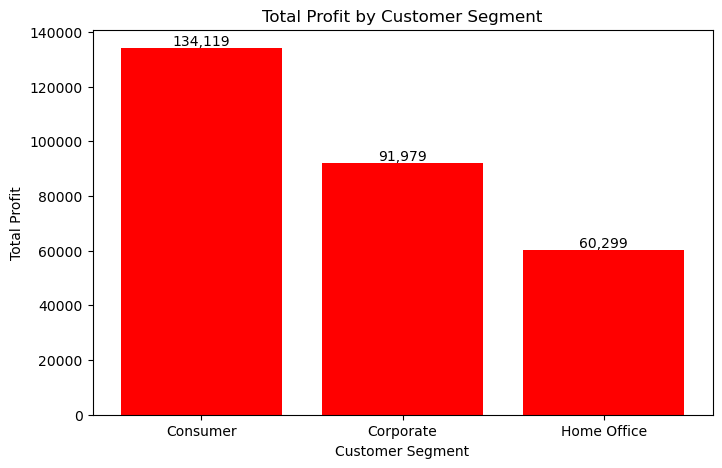

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(segment_profit.index, segment_profit.values, color="red")

for i in range(len(segment_profit)):
    plt.text(
        i,
        segment_profit.values[i] + 1000,
        f'{segment_profit.values[i]:,.0f}',
        ha='center'
    )

plt.title('Total Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit')

## Sales Analysis by Sub-Category

In [30]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

subcategory_sales

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

Text(0, 0.5, 'Sub-Category')

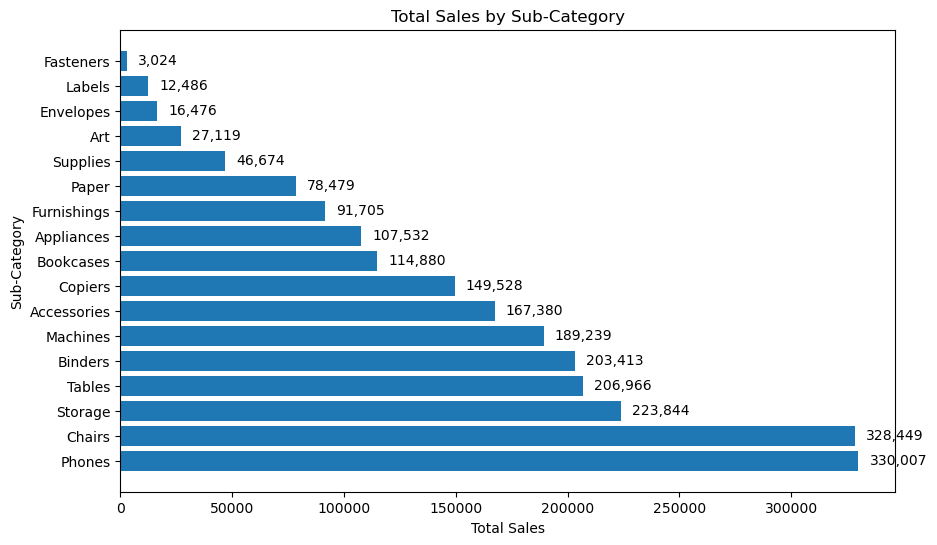

In [31]:
plt.figure(figsize=(10, 6))

plt.barh(subcategory_sales.index, subcategory_sales.values)

for i in range(len(subcategory_sales)):
    plt.text(
        subcategory_sales.values[i] + 5000,
        i,
        f'{subcategory_sales.values[i]:,.0f}',
        va='center'
    )

plt.title('Total Sales by Sub-Category')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')

### Profit Analysis by Sub-Category

In [32]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

subcategory_profit

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

Text(0, 0.5, 'Sub-Category')

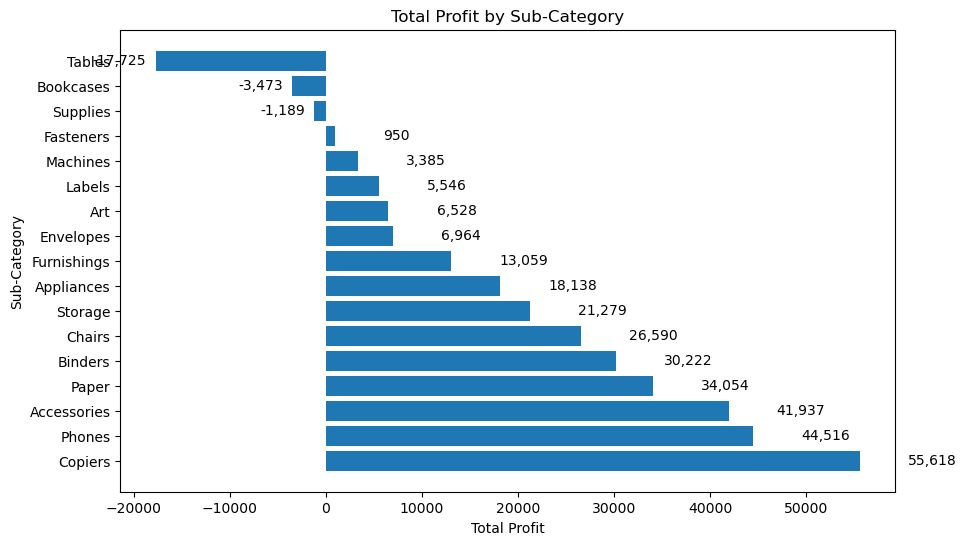

In [33]:
plt.figure(figsize=(10, 6))

plt.barh(subcategory_profit.index, subcategory_profit.values)

for i in range(len(subcategory_profit)):
    profit = subcategory_profit.values[i]

    plt.text(
        profit + 5000 if profit >= 0 else profit - 1000,
        i,
        f'{profit:,.0f}',
        va='center',
        ha='left' if profit >= 0 else 'right'
    )

plt.title('Total Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')

## Sales Trend Over Time

In [34]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales

Order Date
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


In [35]:
df['Order Date'].dt.to_period('M')

0       2016-11
1       2016-11
2       2016-06
3       2015-10
4       2015-10
         ...   
9989    2014-01
9990    2017-02
9991    2017-02
9992    2017-02
9993    2017-05
Name: Order Date, Length: 9994, dtype: period[M]

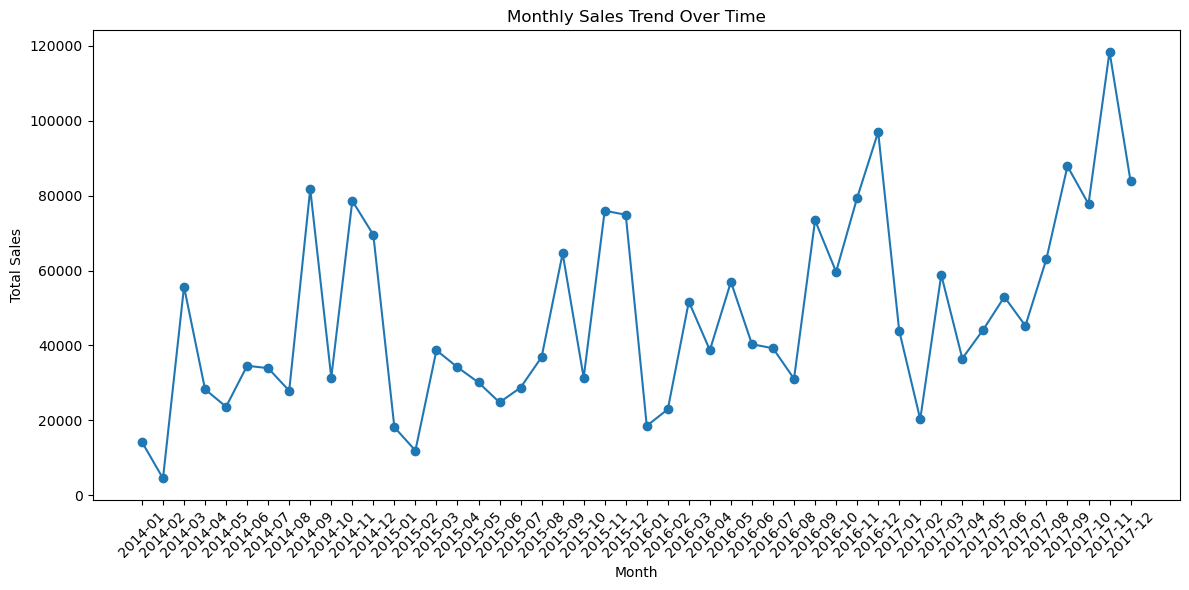

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()

## Profit Trend Over Time

In [37]:
monthly_profit = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Profit'].sum()

monthly_profit

Order Date
2014-01     2450.1907
2014-02      862.3084
2014-03      498.7299
2014-04     3488.8352
2014-05     2738.7096
2014-06     4976.5244
2014-07     -841.4826
2014-08     5318.1050
2014-09     8328.0994
2014-10     3448.2573
2014-11     9292.1269
2014-12     8983.5699
2015-01    -3281.0070
2015-02     2813.8508
2015-03     9732.0978
2015-04     4187.4962
2015-05     4667.8690
2015-06     3335.5572
2015-07     3288.6483
2015-08     5355.8084
2015-09     8209.1627
2015-10     2817.3660
2015-11    12474.7884
2015-12     8016.9659
2016-01     2824.8233
2016-02     5004.5795
2016-03     3611.9680
2016-04     2977.8149
2016-05     8662.1464
2016-06     4750.3781
2016-07     4432.8779
2016-08     2062.0693
2016-09     9328.6576
2016-10    16243.1425
2016-11     4011.4075
2016-12    17885.3093
2017-01     7140.4391
2017-02     1613.8720
2017-03    14751.8915
2017-04      933.2900
2017-05     6342.5828
2017-06     8223.3357
2017-07     6952.6212
2017-08     9040.9557
2017-09    10991.5556

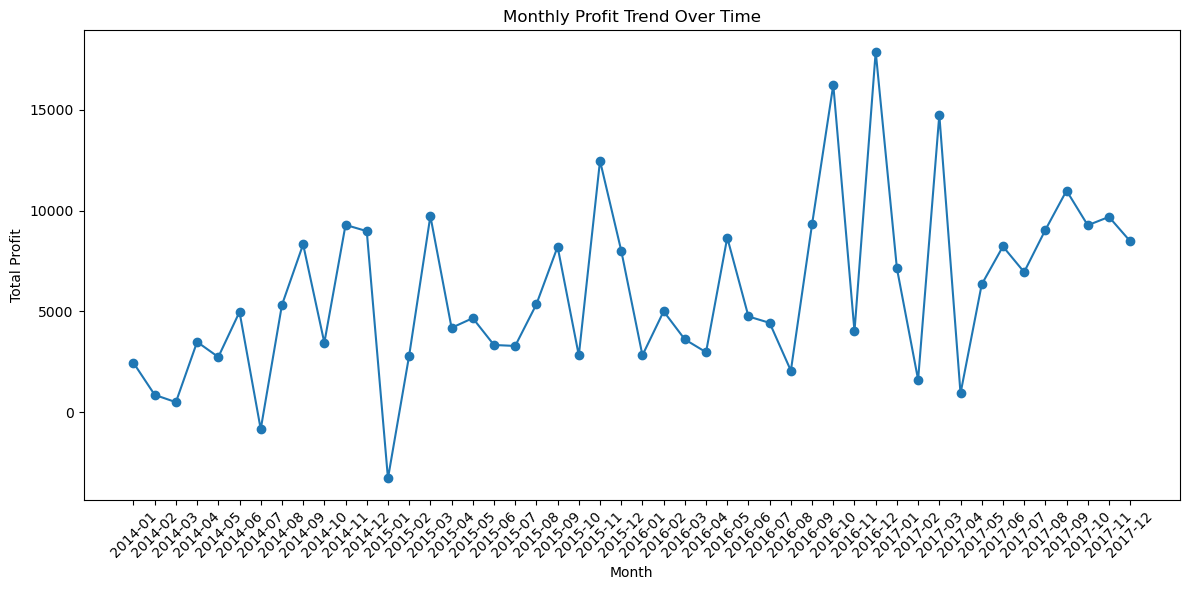

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_profit.index.astype(str),
    monthly_profit.values,
    marker='o'
)

plt.title('Monthly Profit Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Total Profit')

plt.xticks(rotation=45)

plt.tight_layout()

## Discount vs Profit Analysis

In [39]:
discount_profit = df.groupby('Discount')['Profit'].mean()

discount_profit

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

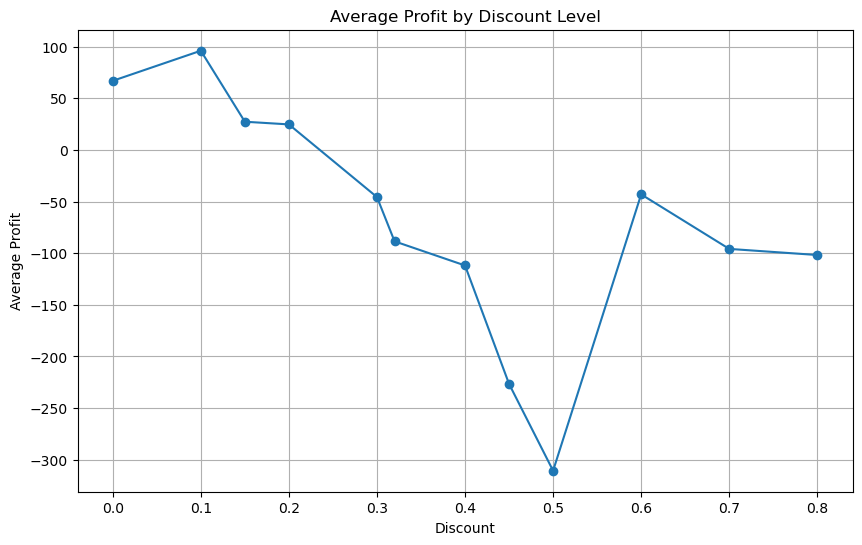

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    discount_profit.index,
    discount_profit.values,
    marker='o'
)

plt.title('Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')

plt.grid()

## State-wise Sales Analysis

In [42]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

state_sales

State
California              457687.6315
New York                310876.2710
Texas                   170188.0458
Washington              138641.2700
Pennsylvania            116511.9140
Florida                  89473.7080
Illinois                 80166.1010
Ohio                     78258.1360
Michigan                 76269.6140
Virginia                 70636.7200
North Carolina           55603.1640
Indiana                  53555.3600
Georgia                  49095.8400
Kentucky                 36591.7500
New Jersey               35764.3120
Arizona                  35282.0010
Wisconsin                32114.6100
Colorado                 32108.1180
Tennessee                30661.8730
Minnesota                29863.1500
Massachusetts            28634.4340
Delaware                 27451.0690
Maryland                 23705.5230
Rhode Island             22627.9560
Missouri                 22205.1500
Oklahoma                 19683.3900
Alabama                  19510.6400
Oregon                

In [43]:
top_10_states_sales = state_sales.head(10)

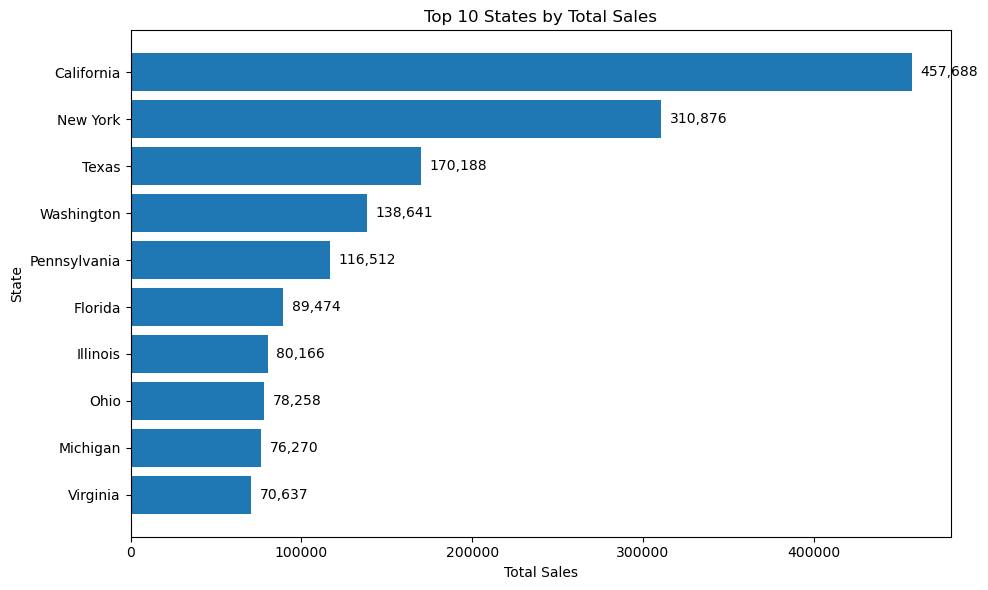

In [44]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_states_sales.index,
    top_10_states_sales.values
)

for i in range(len(top_10_states_sales)):
    plt.text(
        top_10_states_sales.values[i] + 5000,
        i,
        f'{top_10_states_sales.values[i]:,.0f}',
        va='center'
    )

plt.title('Top 10 States by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')

plt.gca().invert_yaxis()

plt.tight_layout()

# Key Insights and Findings

### Key Insights

Based on the exploratory data analysis, the following key insights were identified:

1. **Category Performance:** Sales and profit varied significantly across different product categories, showing that high sales do not always directly translate into the highest profitability.

2. **Regional Performance:** The analysis revealed differences in sales and profit across regions, indicating that geographical location plays an important role in overall business performance.

3. **Customer Segments:** Different customer segments contributed differently to total sales and profit, helping identify which types of customers are the most valuable to the business.

4. **Sub-Category Performance:** A more detailed analysis of sub-categories revealed considerable differences in profitability. Some sub-categories generated strong profits, while others performed poorly despite generating sales.

5. **Sales Trends Over Time:** Monthly sales showed fluctuations over time, highlighting periods of higher and lower business activity and suggesting possible seasonal patterns.

6. **Profit Trends Over Time:** Profit also changed across different months, and higher sales did not always correspond to proportionally higher profits.

7. **Impact of Discounts:** The discount analysis showed that discount levels can significantly affect profitability. Higher discounts may reduce profit and, in some cases, lead to negative profitability.
